# **What is a Brain Tumor ?**
A brain tumor refers to an abnormal collection or mass of cells within the brain. The skull, which encloses the brain, has limited space, and any growth within this confined area can lead to complications. Brain tumors can be either cancerous (malignant) or noncancerous (benign). As benign or malignant tumors grow, they can increase the pressure inside the skull. This elevated pressure can cause brain damage and pose a life-threatening risk.


# **The Importance of Brain Tumor Classification:**
The early detection and classification of brain tumors are crucial areas of research in medical imaging. Accurate classification aids in selecting the most suitable treatment method, potentially saving patients' lives.

# **Methods :**
The application of deep learning approaches in healthcare has yielded significant advancements in health diagnosis. According to the World Health Organization (WHO), effective brain tumor diagnosis involves detecting the tumor, identifying its location within the brain, and classifying it based on malignancy, grade, and type. This experimental work focuses on diagnosing brain tumors using Magnetic Resonance Imaging (MRI). The process entails tumor detection, classification by grade and type, and identification of the tumor's location. Instead of employing individual models for each classification task, this method utilizes a single model for classifying brain MRI images across different classification tasks. The classification and detection of tumors employ a Convolutional Neural Network (CNN)-based multi-task approach. Additionally, a CNN-based model is employed to segment the brain and identify the location of the tumor.


**The dataset focuses on brain tumors and their classification. The four classes are as follows:**

Glioma: Cancerous brain tumors in glial cells.

Meningioma: Non-cancerous tumors originating from the meninges.

No Tumor: Normal brain scans without detectable tumors.

Pituitary: Tumors affecting the pituitary gland, which can be cancerous or non-cancerous.

# 1- Preparing the environement (use a GPU):
Runtime → Change runtime type → Hardware accelerator → T4 GPU

In [ ]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2- Download the Kaggle dataset using KAGGLE API:

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


Checking the dataset's documented structure :

In [ ]:
import os

print(os.listdir(path))

['Training', 'Testing']


In [ ]:
for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "images")

/kaggle/input/brain-tumor-mri-dataset -> 0 images
/kaggle/input/brain-tumor-mri-dataset/Training -> 0 images
/kaggle/input/brain-tumor-mri-dataset/Training/pituitary -> 1400 images
/kaggle/input/brain-tumor-mri-dataset/Training/notumor -> 1400 images
/kaggle/input/brain-tumor-mri-dataset/Training/meningioma -> 1400 images
/kaggle/input/brain-tumor-mri-dataset/Training/glioma -> 1400 images
/kaggle/input/brain-tumor-mri-dataset/Testing -> 0 images
/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary -> 400 images
/kaggle/input/brain-tumor-mri-dataset/Testing/notumor -> 400 images
/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma -> 400 images
/kaggle/input/brain-tumor-mri-dataset/Testing/glioma -> 400 images


Check that:
*   the dataset downloaded correctly
*   all four classes exist
*   the classes are reasonably balanced
*   there aren't obvious missing folders

---> in our case: the dataset is balanced

In [ ]:
import os
import pandas as pd

splits = ["Training", "Testing"]

data = []

for split in splits:
    for class_name in sorted(
        os.listdir(os.path.join(path, split))
    ):
        class_path = os.path.join(
            path, split, class_name
        )

        if os.path.isdir(class_path):
            n_images = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(
                    (".jpg", ".jpeg", ".png", ".bmp")
                )
            ])

            data.append({
                "Split": split,
                "Class": class_name,
                "Number of images": n_images
            })

df = pd.DataFrame(data)
display(df)

,Split,Class,Number of images
0,Training,glioma,1400
1,Training,meningioma,1400
2,Training,notumor,1400
3,Training,pituitary,1400
4,Testing,glioma,400
5,Testing,meningioma,400
6,Testing,notumor,400
7,Testing,pituitary,400


Check the classes distribution :

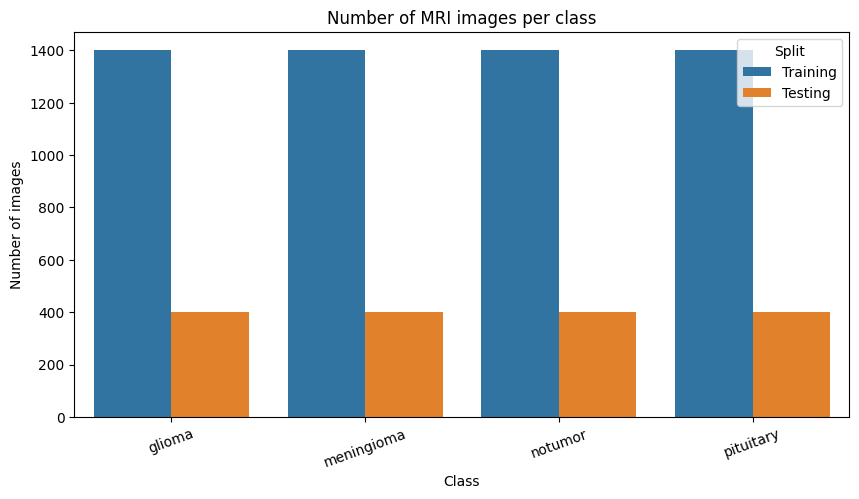

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Class",
    y="Number of images",
    hue="Split"
)

plt.title("Number of MRI images per class")
plt.xticks(rotation=20)
plt.show()

Display images from each class :

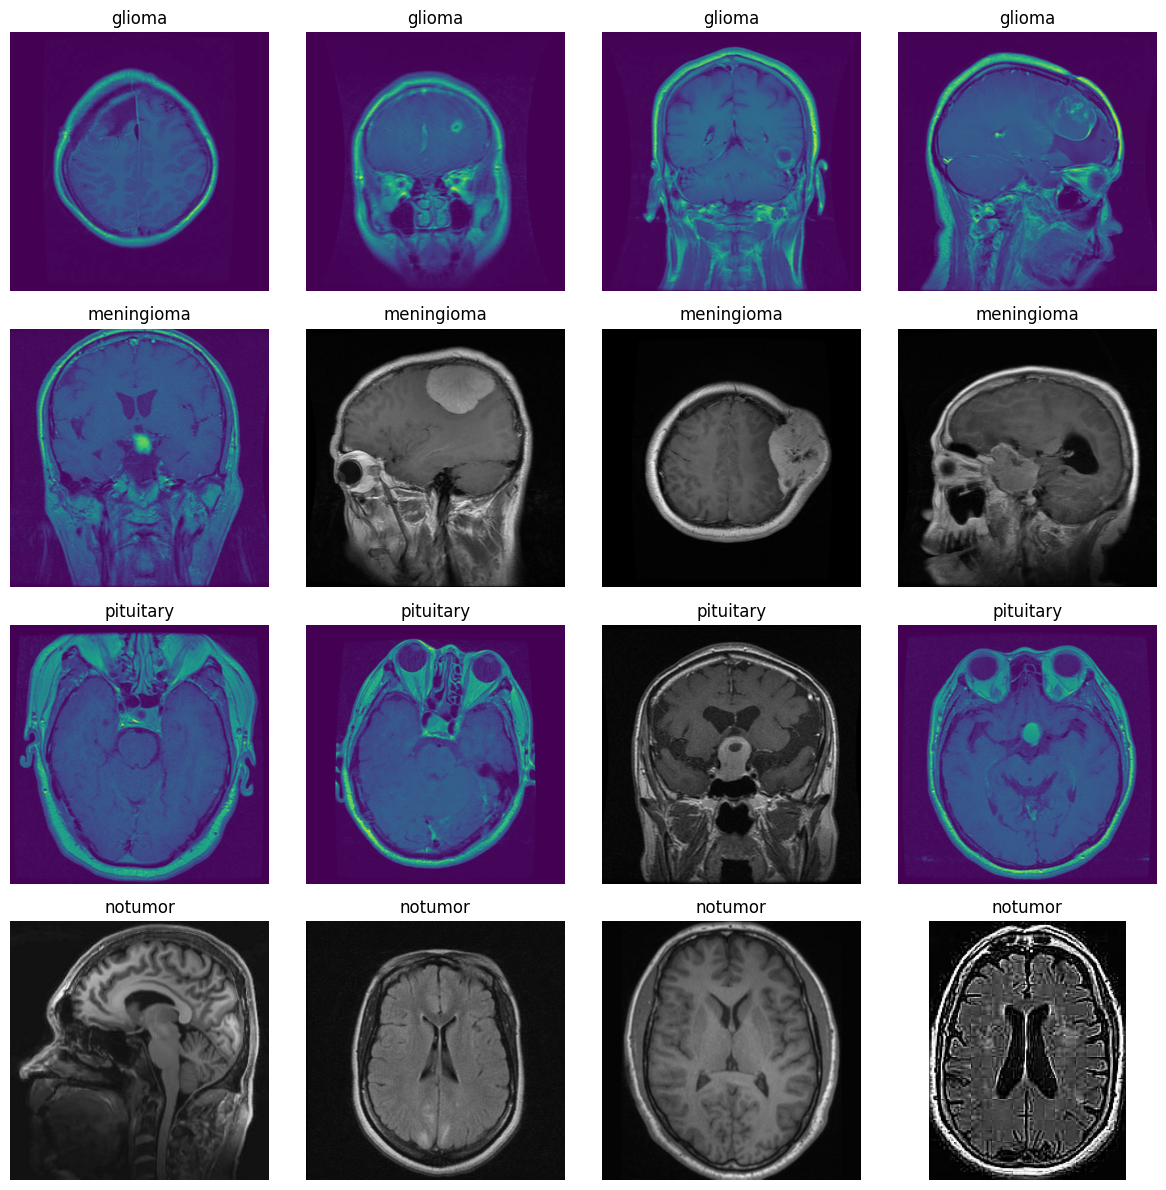

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

classes = ["glioma", "meningioma",
           "pituitary", "notumor"]

fig, axes = plt.subplots(
    4, 4, figsize=(12, 12)
)

for row, class_name in enumerate(classes):

    folder = os.path.join(
        path, "Training", class_name
    )

    image_files = [
        f for f in os.listdir(folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp")
        )
    ]

    samples = random.sample(
        image_files, min(4, len(image_files))
    )

    for col, filename in enumerate(samples):
        img = Image.open(
            os.path.join(folder, filename)
        )

        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# **3- EDA and preprocessing for MRI images:**

Examine image dimensions and color modes:

In [ ]:
from PIL import Image
from collections import Counter

image_sizes = Counter()
image_modes = Counter()

for class_name in classes:

    folder = os.path.join(
        path, "Training", class_name
    )

    for filename in os.listdir(folder):
        image_path = os.path.join(
            folder, filename
        )

        try:
            with Image.open(image_path) as img:
                image_sizes[img.size] += 1
                image_modes[img.mode] += 1

        except Exception as e:
            print("Could not read:", image_path)

print("Most common image sizes:")
print(image_sizes.most_common(10))

print("\nImage modes:")
print(image_modes)

Most common image sizes:
[((512, 512), 4012), ((225, 225), 253), ((630, 630), 69), ((201, 251), 40), ((236, 236), 39), ((442, 442), 38), ((150, 198), 33), ((232, 217), 32), ((228, 221), 32), ((428, 417), 31)]

Image modes:
Counter({'RGB': 3238, 'L': 2358, 'RGBA': 3, 'P': 1})


Inspect pixel values :

In [ ]:
import numpy as np
from PIL import Image
import os

image_path = os.path.join(
    path, "Training", "glioma",
    os.listdir(
        os.path.join(path, "Training", "glioma")
    )[0]
)

img = Image.open(image_path).convert("RGB")

img_array = np.array(img)

print("Image shape:", img_array.shape)
print("Data type:", img_array.dtype)
print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:", img_array.max())
print("Mean pixel value:", img_array.mean())

Image shape: (512, 512, 3)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 25.379104614257812


# **Preprocessing operations :**

# 1: Resizing

Because the CNN expects the same dimensions for every image in a batch.
We **resize** To ensure that all images have a consistent shape, so they can be grouped into batches and passed through the same neural network.

Note: resizing changes the spatial resolution and can distort the image's aspect ratio if the original dimensions differ.

In [ ]:
img_tensor = tf.image.resize(
    img_array,
    (224, 224)
)

# 2: Normalization

Resizing changes the image dimensions. Normalization changes the numerical scale of the pixels.
Suppose a pixel has value: 128
We divide it by 255: 128/255 ≈0.502
Now the pixels are in the range 0–1.

Why? Scaling inputs can help neural network optimization behave more smoothly.

In [ ]:
img_normalized = tf.cast(
    img_tensor, tf.float32
) / 255.0

In [ ]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

**Create training and validation datasets**

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, "Training"),
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, "Training"),
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


**Load the test dataset:**
The test set should remain separate from the training and validation sets while you develop your model.

In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(path, "Testing"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

Found 1600 files belonging to 4 classes.


**Verify your preprocessing worked :**

Before building the CNN, inspect a batch:

In [ ]:
for images, labels in train_ds.take(1):

    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Pixel minimum:", tf.reduce_min(images).numpy())
    print("Pixel maximum:", tf.reduce_max(images).numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Pixel minimum: 0.0
Pixel maximum: 255.0


adding Augmentation, normalization, and speed-up:
Augmentation: It creates modified versions of training images to help the model learn from image variations rather than simply memorizing its training examples.
These transformations are applied randomly during training.



In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, models

# Augmentation: only active during training, automatically off for validation/test
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.1),
], name="augmentation")

# Faster input pipeline (train/val only, so test_ds.class_names keeps working)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# Building the CNN model :

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

image_shape = (224, 224, 3)
N_TYPES = 4

# CNN architecture
model = models.Sequential()

# Convolutional layer 1
model.add(Conv2D(32, (4, 4), activation="relu", input_shape=image_shape))
model.add(MaxPooling2D(pool_size=(3, 3)))

# Convolutional layer 2
model.add(Conv2D(64, (4, 4), activation="relu"))
model.add(MaxPooling2D(pool_size=(3, 3)))

# Convolutional layer 3
model.add(Conv2D(128, (4, 4), activation="relu"))
model.add(MaxPooling2D(pool_size=(3, 3)))

# Convolutional layer 4
model.add(Conv2D(128, (4, 4), activation="relu"))
model.add(Flatten())

# Full connect layers
model.add(Dense(512, activation="relu"))
model.add(Dropout(0.5, seed=SEED))
model.add(Dense(N_TYPES, activation="softmax"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Inspect the architecture :**

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 221, 221, 32)   │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 70, 70, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 20, 20, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,020,260 (3.89 MB)

 Trainable params: 1,020,260 (3.89 MB)

 Non-trainable params: 0 (0.00 B)

**Compile the model :**

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**Train the model :**

In [ ]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - accuracy: 0.5958 - loss: 1.7546 - val_accuracy: 0.7241 - val_loss: 0.6527
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.7496 - loss: 0.6031 - val_accuracy: 0.8080 - val_loss: 0.4622
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.8317 - loss: 0.4296 - val_accuracy: 0.8518 - val_loss: 0.4340
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.8763 - loss: 0.3239 - val_accuracy: 0.8902 - val_loss: 0.2765
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.9036 - loss: 0.2630 - val_accuracy: 0.8938 - val_loss: 0.2895
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 0.9225 - loss: 0.2070 - val_accuracy: 0.8955 - val_loss: 0.3033
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9364 - loss: 0.1647 - val_accuracy: 0.8955 - val_loss: 0.3204
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.9279 - loss: 0.1924 - val

**Evaluate the model : **

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test accuracy:", test_accuracy)

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8556 - loss: 0.9537
Test accuracy: 0.8556249737739563


**Plot the accuracy :**

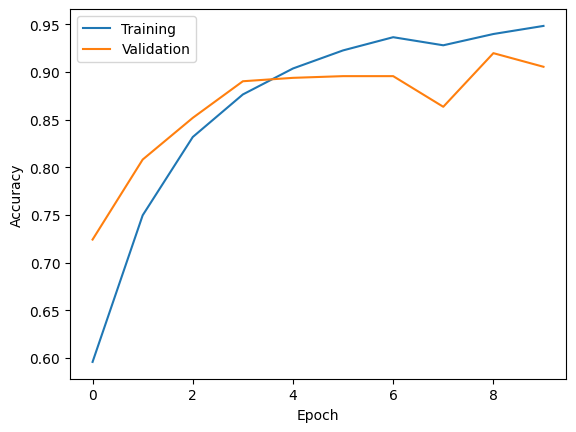

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Making predictions :

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

## Confusion matrix :

['glioma', 'meningioma', 'notumor', 'pituitary']


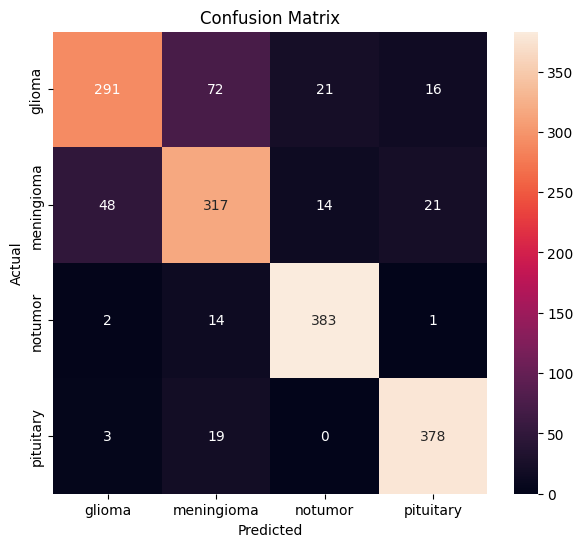

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_names = test_ds.class_names

print(class_names)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Get detailed statistics :**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.85      0.73      0.78       400
  meningioma       0.75      0.79      0.77       400
     notumor       0.92      0.96      0.94       400
   pituitary       0.91      0.94      0.93       400

    accuracy                           0.86      1600
   macro avg       0.86      0.86      0.85      1600
weighted avg       0.86      0.86      0.85      1600

